# Car Price Prediction Project
**Goal**: Predict Selling_Price using the provided dataset (`car data.csv`)

## Step 1: Data Loading & Cleaning

In [1]:
# ==============================
# Cell 1: Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style='darkgrid', palette='muted')


In [2]:
# ==============================
# Cell 2: Load Dataset
# ==============================
# Load dataset
try:
    df = pd.read_csv('car data.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'car data.csv' not found. Please upload the dataset.")

# Display basic info
display(df.head())
print("\nDataset Shape:", df.shape)
print("\nDataset Info:")
display(df.info())
print("\nDataset Describe:")
display(df.describe())


Dataset loaded successfully!


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Dataset Shape: (301, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


None


Dataset Describe:


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [3]:
# ==============================
# Cell 3: Data Cleaning & Feature Engineering
# ==============================
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Check for duplicates and drop them
print("\nDuplicates before dropping:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after dropping:", df.duplicated().sum())

# Feature Engineering: Calculate Car Age
current_year = 2024
df['Car_Age'] = current_year - df['Year']

# Drop unnecessary columns
# 'Car_Name' is generally dropped as it creates too many categories and 'Year' is replaced by 'Car_Age'
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

display(df.head())


Missing Values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicates before dropping: 2
Duplicates after dropping: 0


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


## Step 2: Exploratory Data Analysis (EDA)

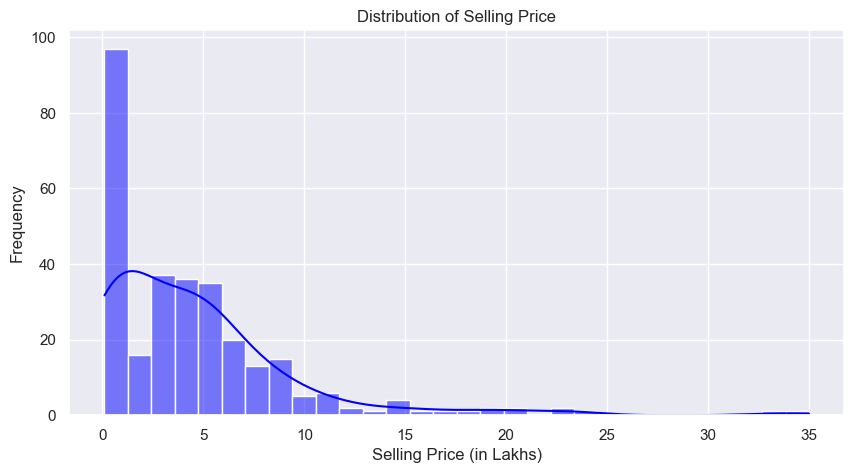

In [4]:
# ==============================
# Cell 4: EDA - Selling Price Distribution
# ==============================
plt.figure(figsize=(10, 5))
sns.histplot(df['Selling_Price'], kde=True, color='blue', bins=30)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Frequency')
plt.show()

# Insight: The selling price is right-skewed, meaning most cars are sold at lower prices (under 10 Lakhs).


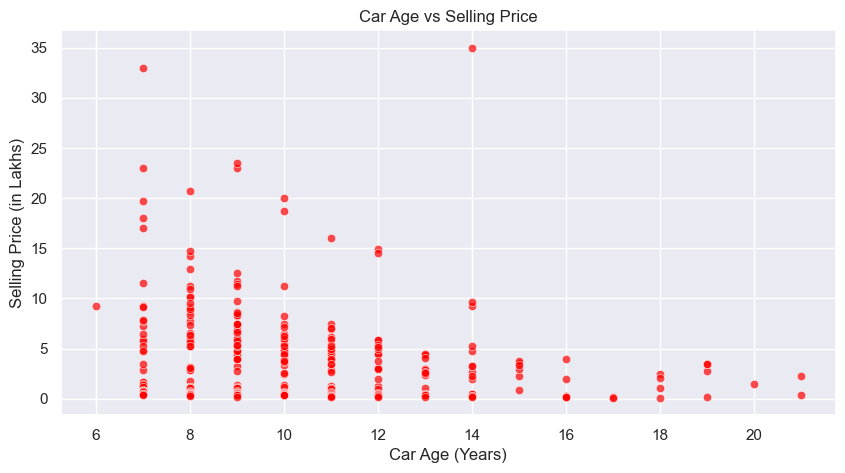

In [5]:
# ==============================
# Cell 5: EDA - Car Age vs Price
# ==============================
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df, color='red', alpha=0.7)
plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

# Insight: As the car gets older, its selling price generally decreases.


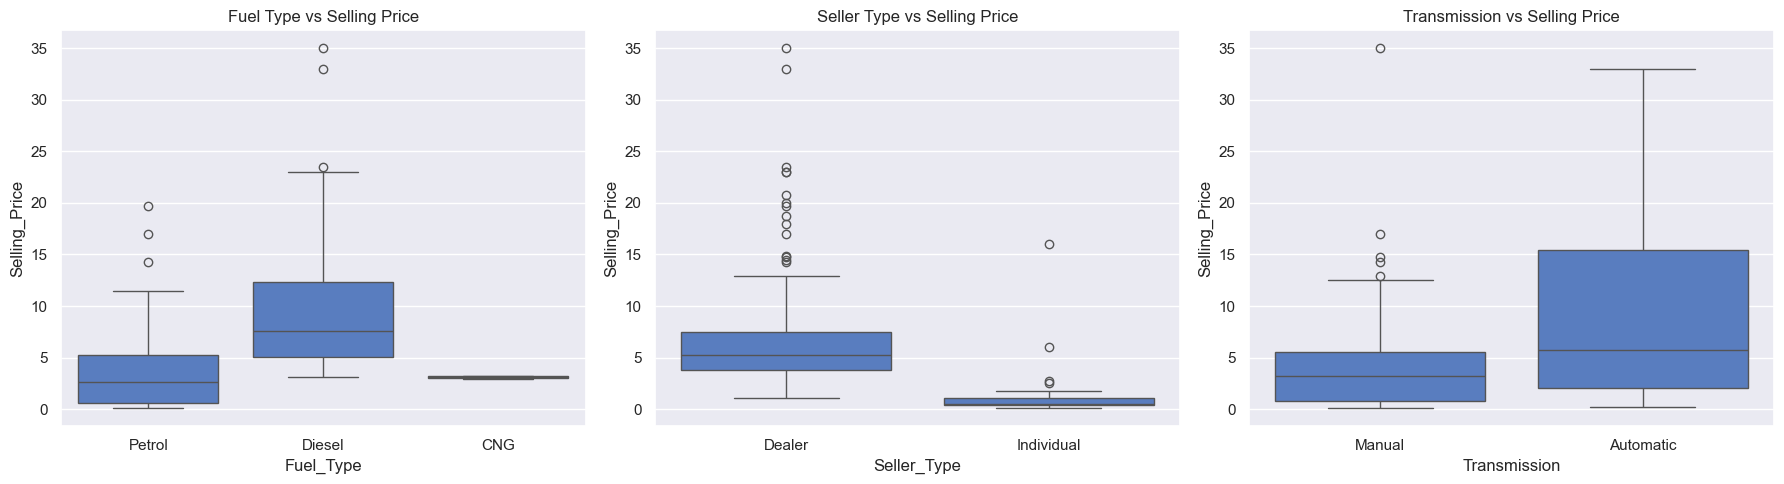

In [6]:
# ==============================
# Cell 6: EDA - Categorical Variables vs Price
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, ax=axes[0])
axes[0].set_title('Fuel Type vs Selling Price')
# Insight: Diesel cars tend to have a higher median selling price than Petrol or CNG cars.

sns.boxplot(x='Seller_Type', y='Selling_Price', data=df, ax=axes[1])
axes[1].set_title('Seller Type vs Selling Price')
# Insight: Cars sold by dealers have higher prices compared to individual sellers.

sns.boxplot(x='Transmission', y='Selling_Price', data=df, ax=axes[2])
axes[2].set_title('Transmission vs Selling Price')
# Insight: Automatic transmission cars have a significantly higher selling price than manual cars.

plt.tight_layout()
plt.show()


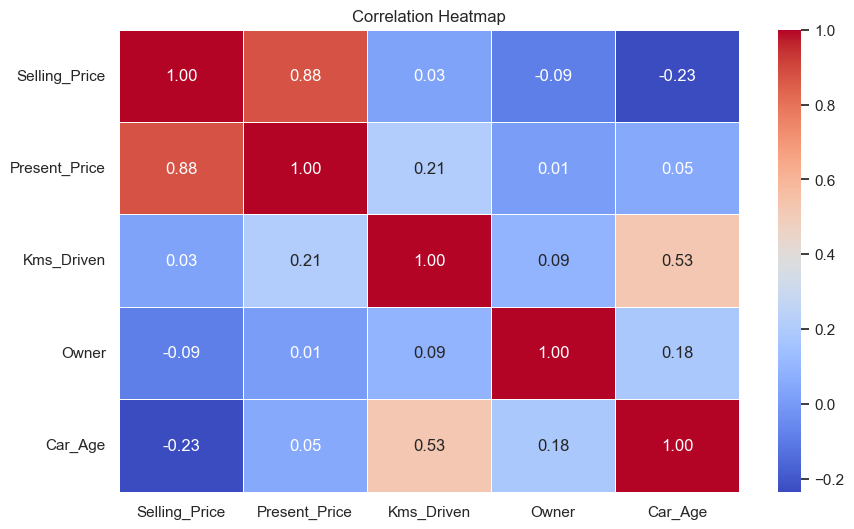

In [7]:
# ==============================
# Cell 7: EDA - Correlation Heatmap
# ==============================
plt.figure(figsize=(10, 6))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Insight: Present_Price has a strong positive correlation with Selling_Price, while Car_Age has a negative correlation.


## Step 3: Data Preprocessing

In [8]:
# ==============================
# Cell 8: Categorical Encoding (One-Hot Encoding)
# ==============================
# Convert categorical variables using One-Hot Encoding
df = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

display(df.head())


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


In [9]:
# ==============================
# Cell 9: Feature Selection & Split
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")


Training data shape: (239, 8)
Testing data shape: (60, 8)


## Step 4 & 5: Model Building & Evaluation

In [10]:
# ==============================
# Cell 10: Model Training and Evaluation
# ==============================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

# Function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return r2, mae, rmse

# Train and collect results
results = []
for name, model in models.items():
    r2, mae, rmse = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test)
    results.append([name, r2, mae, rmse])

# Display Results
results_df = pd.DataFrame(results, columns=['Model', 'R² Score', 'MAE', 'RMSE'])
display(results_df.sort_values(by='R² Score', ascending=False))


,Model,R² Score,MAE,RMSE
3,XGBoost,0.770167,1.128754,2.433836
0,Linear Regression,0.752815,1.472892,2.524035
1,Decision Tree,0.670113,1.333333,2.915863
2,Random Forest,0.547558,1.435595,3.414807


## Step 6: Hyperparameter Tuning (Advanced)

In [11]:
# ==============================
# Cell 11: Hyperparameter Tuning (Random Forest)
# ==============================
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=10, cv=5, verbose=1, random_state=42, n_jobs=-1
)

rf_random.fit(X_train_scaled, y_train)

best_rf = rf_random.best_estimator_
print("Best Random Forest Parameters:", rf_random.best_params_)

# Evaluate best model
y_pred_best = best_rf.predict(X_test_scaled)
print("\nTuned Random Forest R² Score:", r2_score(y_test, y_pred_best))
print("Tuned Random Forest MAE:", mean_absolute_error(y_test, y_pred_best))
print("Tuned Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))


Fitting 5 folds for each of 10 candidates, totalling 50 fits


Best Random Forest Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}

Tuned Random Forest R² Score: 0.7535217923681794
Tuned Random Forest MAE: 1.1355142033738252
Tuned Random Forest RMSE: 2.520426050761705


## Step 7 & 9: Final Model, Prediction Function & Bonus Plots

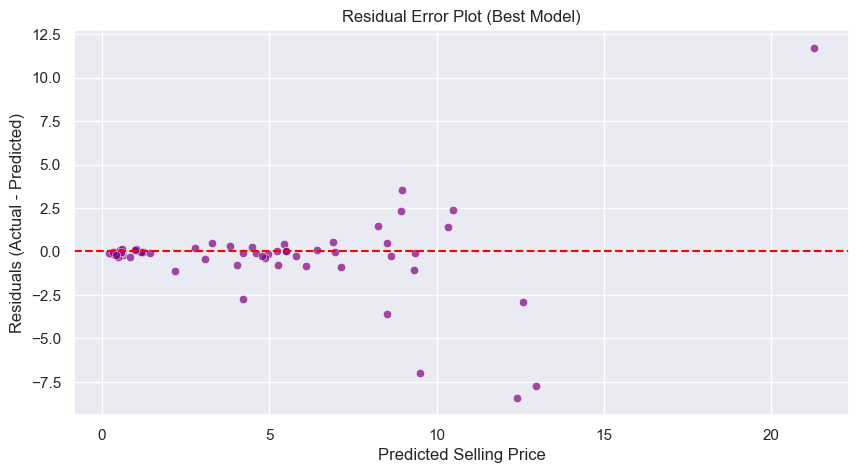

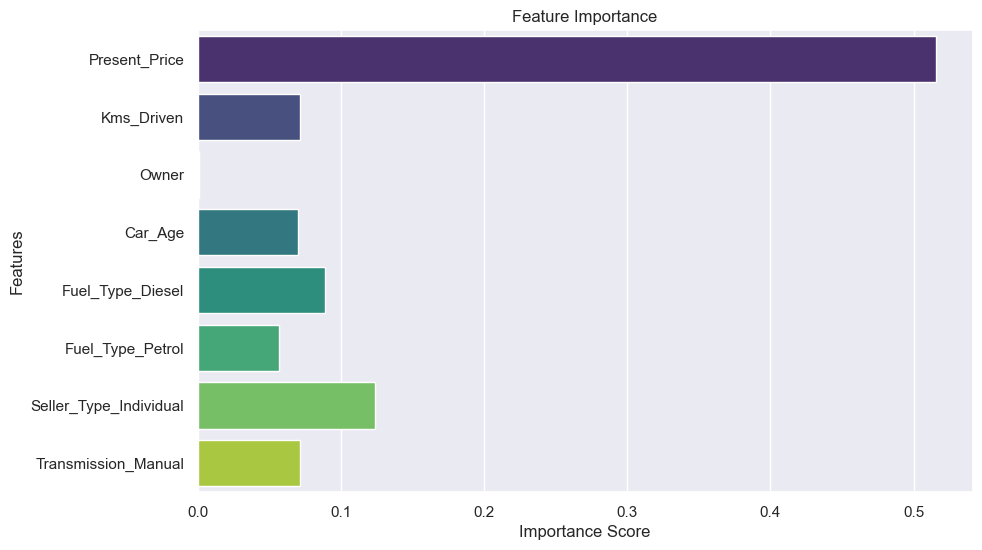

In [12]:
# ==============================
# Cell 12: Residuals and Feature Importance (Bonus)
# ==============================
# Residual Error Plot
plt.figure(figsize=(10, 5))
residuals = y_test - y_pred_best
sns.scatterplot(x=y_pred_best, y=residuals, color='purple', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Error Plot (Best Model)')
plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()
# Insight: Residuals are randomly scattered around zero, indicating a good fit.

# Feature Importance Plot
plt.figure(figsize=(10, 6))
feature_importances = best_rf.feature_importances_
sns.barplot(x=feature_importances, y=X.columns, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()
# Insight: Present_Price is the most dominant feature in predicting the selling price.


In [13]:
# ==============================
# Cell 13: Save Final Model and Create Predict Function
# ==============================
import pickle

# Save the scaler and the model
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

with open('car_price_model.pkl', 'wb') as file:
    pickle.dump(best_rf, file)

print("Model and Scaler saved successfully as 'car_price_model.pkl' and 'scaler.pkl'")

# Define Prediction Function
def predict_car_price(Present_Price, Kms_Driven, Owner, Car_Age, Fuel_Type, Seller_Type, Transmission):
    # Map inputs to model columns
    # We need to ensure the structure matches our trained X dataframe exactly.
    input_data = {
        'Present_Price': [Present_Price],
        'Kms_Driven': [Kms_Driven],
        'Owner': [Owner],
        'Car_Age': [Car_Age],
        'Fuel_Type_Diesel': [1 if Fuel_Type == 'Diesel' else 0],
        'Fuel_Type_Petrol': [1 if Fuel_Type == 'Petrol' else 0],
        'Seller_Type_Individual': [1 if Seller_Type == 'Individual' else 0],
        'Transmission_Manual': [1 if Transmission == 'Manual' else 0]
    }
    
    # Convert to DataFrame to ensure correct column order
    input_df = pd.DataFrame(input_data, columns=X.columns)
    
    # Scale features
    with open('scaler.pkl', 'rb') as f:
        loaded_scaler = pickle.load(f)
    
    input_scaled = loaded_scaler.transform(input_df)
    
    # Load model and predict
    with open('car_price_model.pkl', 'rb') as f:
        loaded_model = pickle.load(f)
        
    prediction = loaded_model.predict(input_scaled)
    return round(prediction[0], 2)

# Test the prediction function
test_price = predict_car_price(Present_Price=5.59, Kms_Driven=27000, Owner=0, Car_Age=10, 
                               Fuel_Type='Petrol', Seller_Type='Dealer', Transmission='Manual')
print(f"\nSample Prediction Output: ₹ {test_price} Lakhs")


Model and Scaler saved successfully as 'car_price_model.pkl' and 'scaler.pkl'

Sample Prediction Output: ₹ 3.72 Lakhs
